# Churn Analizi / Churn Analysis

1. Kütüphanelerin Yüklenmesi / Import Libraries & Dependencies

In [ ]:
!pip install -q xgboost

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize']=(10,6)
plt.rcParams['font.size']=12
sns.set_style('whitegrid')

2. Veri setinin yüklenmesi / Dataset Loading

In [ ]:
# IBM Telco Müşteri Kayıp Veri Seti / IBM Telco Customer Churn Dataset
url = r"https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

In [ ]:
df=pd.read_csv(url)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<table>
  <thead>
    <tr>
      <th>Sütun</th>
      <th>Açıklama</th>
      <th>Tip</th>
    </tr>
  </thead>
  <tbody>
    <tr><td><code>customerID</code></td><td>Benzersiz müşteri kimliği</td><td>ID</td></tr>
    <tr><td><code>gender</code></td><td>Cinsiyet (Male/Female)</td><td>Kategorik</td></tr>
    <tr><td><code>SeniorCitizen</code></td><td>65 yaş üstü mü? (0/1)</td><td>Binary</td></tr>
    <tr><td><code>tenure</code></td><td>Müşteri süresi (ay)</td><td>Sayısal</td></tr>
    <tr><td><code>Contract</code></td><td>Sözleşme türü (Aylık/1 Yıl/2 Yıl)</td><td>Kategorik</td></tr>
    <tr><td><code>MonthlyCharges</code></td><td>Aylık ücret ($)</td><td>Sayısal</td></tr>
    <tr><td><code>TotalCharges</code></td><td>Toplam ödenen tutar ($)</td><td>Sayısal</td></tr>
    <tr><td><code>InternetService</code></td><td>İnternet hizmet türü (DSL/Fiber/Yok)</td><td>Kategorik</td></tr>
    <tr><td><code>PaymentMethod</code></td><td>Ödeme yöntemi</td><td>Kategorik</td></tr>
    <tr><td><code>TechSupport</code></td><td>Teknik destek var mı?</td><td>Kategorik</td></tr>
    <tr style="font-weight: bold; background-color: #f9f9f9;">
      <td><code>Churn</code></td>
      <td>Müşteri terk etti mi? (Yes/No)</td>
      <td>Hedef (Target)</td>
    </tr>
  </tbody>
</table>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.Churn

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


In [ ]:
# Churn sütununu 0/1 e çevir / Convert churn column to binary (0/1)
df['Churn_Flag']=(df['Churn']=='Yes' ).astype(int)
df['Churn_Flag']

,Churn_Flag
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


<Axes: ylabel='count'>

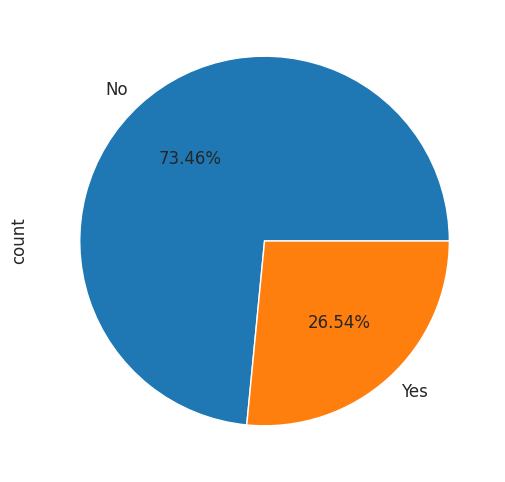

In [ ]:
df.Churn.value_counts().plot(kind='pie',
                             autopct='%.2f%%')

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


<Axes: ylabel='count'>

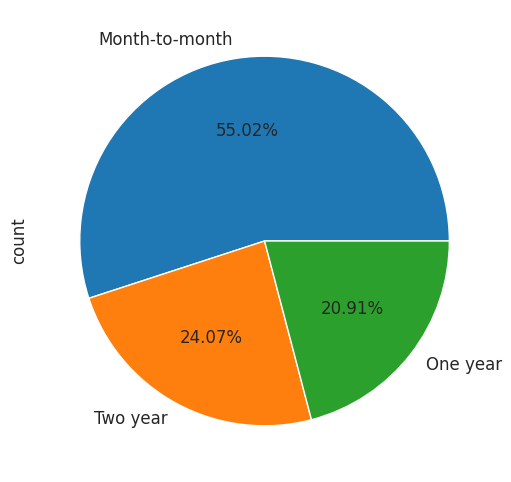

In [ ]:
df.Contract.value_counts().plot(kind='pie',
                             autopct='%.2f%%')

In [ ]:
df.groupby('Contract')['Churn'].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

In [ ]:
df.groupby('gender')['Churn'].value_counts()

gender  Churn
Female  No       2549
        Yes       939
Male    No       2625
        Yes       930
Name: count, dtype: int64

In [ ]:
df.groupby('InternetService')['Churn'].value_counts()

InternetService  Churn
DSL              No       1962
                 Yes       459
Fiber optic      No       1799
                 Yes      1297
No               No       1413
                 Yes       113
Name: count, dtype: int64

In [ ]:
df.groupby('InternetService')['Churn'].value_counts(normalize=True)

InternetService  Churn
DSL              No       0.810409
                 Yes      0.189591
Fiber optic      No       0.581072
                 Yes      0.418928
No               No       0.925950
                 Yes      0.074050
Name: proportion, dtype: float64

<Axes: >

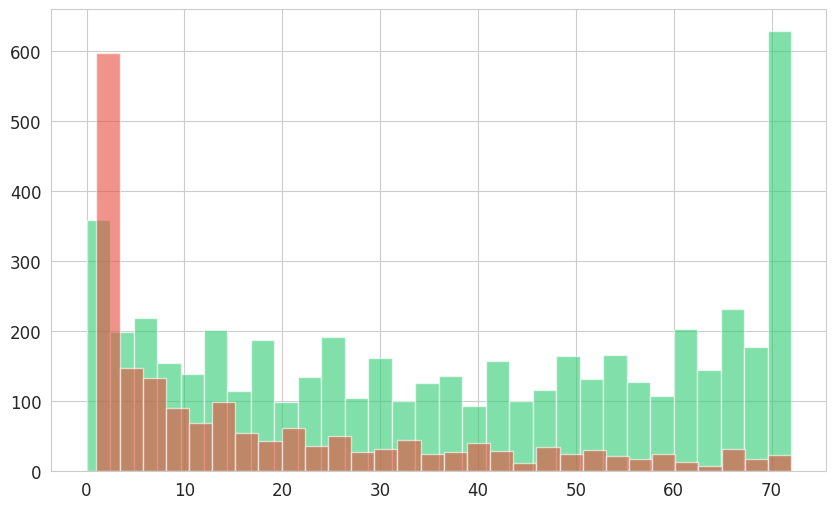

In [ ]:
#  Müşteri süresi dağılımı (terk durumuna göre) /  Customer tenure distribution by churn status
df[df['Churn'] == 'No']['tenure'].hist(bins=30, alpha=0.6,
                                        color='#2ecc71', label='Kalan')
df[df['Churn'] == 'Yes']['tenure'].hist(bins=30, alpha=0.6,
                                         color='#e74c3c', label='Terk Eden')

## Özellik Mühendisliği

In [ ]:
# orijinal veriyi koruyarak kopyalama / Create a copy to preserve the original data
df_model=df.copy()

In [ ]:
# kategorik değişkenleri sayıya çevirme / Convert categorical variables to numerical
le_encoder=LabelEncoder()
df_model['Contract_encoded']=le_encoder.fit_transform(df_model['Contract'])

In [ ]:
le_payment=LabelEncoder()
df_model['PaymentMethod_encoded']=le_encoder.fit_transform(df_model['PaymentMethod'])

In [ ]:
df_model['PaymentMethod_encoded']

,PaymentMethod_encoded
0,2
1,3
2,3
3,0
4,2
...,...
7038,3
7039,1
7040,2
7041,3


In [ ]:
le_internet=LabelEncoder()
df_model['InternetService_encoded']=le_encoder.fit_transform(df_model['InternetService'])

In [ ]:
le_tech=LabelEncoder()
df_model['TechSUpport_encoded']=le_encoder.fit_transform(df_model['TechSupport'])

In [ ]:
df_model['tenure'].min()

0

In [ ]:
df_model['TotalCharges']

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.5
7039,7362.9
7040,346.45
7041,306.6


In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerID               7043 non-null   object 
 1   gender                   7043 non-null   object 
 2   SeniorCitizen            7043 non-null   int64  
 3   Partner                  7043 non-null   object 
 4   Dependents               7043 non-null   object 
 5   tenure                   7043 non-null   int64  
 6   PhoneService             7043 non-null   object 
 7   MultipleLines            7043 non-null   object 
 8   InternetService          7043 non-null   object 
 9   OnlineSecurity           7043 non-null   object 
 10  OnlineBackup             7043 non-null   object 
 11  DeviceProtection         7043 non-null   object 
 12  TechSupport              7043 non-null   object 
 13  StreamingTV              7043 non-null   object 
 14  StreamingMovies         

In [ ]:
df_model['TotalCharges']=pd.to_numeric(df_model['TotalCharges'], errors='coerce')
df_model['TotalCharges'].fillna(df_model['TotalCharges'].median(), inplace=True)

In [ ]:
# yeni özellikler türetelim / Feature engineering
# aylık ortalama harcama / Average monthly charges
df_model['AvgMonthlySpend']=df_model['TotalCharges']/df_model['tenure'].clip(1)
# tenure sütunundaki değer en az 1. ise işlem yapılır


In [ ]:
# yeni müşteri mi? / Is new customer?
df_model['IsNewCustomer']=(df_model['tenure']<6).astype(int)
# yüksek harcama yapanlar
df_model['HighSpender'] = (df_model['MonthlyCharges'] > df_model['MonthlyCharges'].median()).astype(int)

In [ ]:
# model için kullanılacak özellikler / Features to be used for the model
feature_cols=[
    'tenure','MonthlyCharges','TotalCharges','Contract_encoded',
    'PaymentMethod_encoded','InternetService_encoded','TechSUpport_encoded',
    'AvgMonthlySpend','IsNewCustomer','HighSpender'
]

In [ ]:
# veri setini özellikler ve hedef olarak belirle / Split the dataset into features and target
X=df_model[feature_cols]
y=df_model["Churn_Flag"]

In [ ]:
# veri setini eğitim ve test olarak böl / Split the dataset into train and test sets
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=.2,
    random_state=42,
    stratify=y
    )

In [ ]:
X_train.shape, X_test.shape

((5634, 10), (1409, 10))

In [ ]:
y_train.value_counts(normalize=True)

,proportion
Churn_Flag,
0,0.734647
1,0.265353


In [ ]:
y_test.value_counts(normalize=True)

,proportion
Churn_Flag,
0,0.734564
1,0.265436


In [ ]:
y_train.shape[0], y_test.shape[0]

(5634, 1409)

# Model Oluşturma (XGBoost Ensemble) / Model building

5. XGBoost Model Eğitimi / Train XGBoost model

### XGBoost Nedir?

XGBoost (eXtreme Gradient Boosting), zayıf öğrenicileri (küçük karar ağaçları) sırayla birleştirerek güçlü bir model oluşturan ensemble algoritmadır.

/

### What is XGBoost?
XGBoost (eXtreme Gradient Boosting) is an ensemble algorithm that builds a strong model by sequentially combining weak learners (small decision trees).

### Hiperparametre Açıklamaları

| Parametre | Değer | Açıklama |
|-----------|-------|----------|
| `n_estimators` | 200 | Kaç ağaç oluşturulacak (çok = güçlü ama yavaş) |
| `max_depth` | 4 | Her ağacın maksimum derinliği (yüksek = overfitting riski) |
| `learning_rate` | 0.1 | Her ağacın katkı oranı (düşük = daha dikkatli öğrenme) |
| `subsample` | 0.8 | Her ağaçta verinin %80'i kullanılır (overfitting önler) |
| `colsample_bytree` | 0.8 | Her ağaçta özelliklerin %80'i kullanılır |


> **Eğitim ve Test doğruluğu arasındaki fark** overfitting göstergesidir. Fark büyükse model eğitim verisini ezberlemiş demektir.

/

### Hyperparameter Descriptions

| Parameter | Value | Description |
|-----------|-------|-------------|
| `n_estimators` | 200 | Number of trees to build (higher = stronger but slower) |
| `max_depth` | 4 | Maximum depth of each tree (higher = overfitting risk) |
| `learning_rate` | 0.1 | Contribution rate of each tree (lower = more cautious learning) |
| `subsample` | 0.8 | 80% of data is used for each tree (prevents overfitting) |
| `colsample_bytree` | 0.8 | 80% of features are used for each tree |


> **The difference between training and test accuracy** is an indicator of overfitting. If the gap is large, it means the model has memorized the training data.


In [ ]:
from numpy.random import exponential
from os import EX_PROTOCOL

# modelin parametreleri / Model hyperparameters

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

In [ ]:
# modelin eğitilmesi / Model training
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# değerlendirilmesi /  Model evaluation
# tahminler / Predictions
y_pred=xgb_model.predict(X_test)
y_proba=xgb_model.predict_proba(X_test)[:,1]
df_predict=pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred,
    'Probability':y_proba
})
df_predict

,Actual,Predicted,Probability
437,0,0,0.014278
2280,0,1,0.768364
2235,0,0,0.156251
4460,0,0,0.439458
3761,0,0,0.008042
...,...,...,...
5143,0,0,0.034051
4439,0,0,0.002690
3857,0,0,0.181526
4758,0,0,0.091218


In [ ]:
# eğitim doğruluğu / training accuracy
xgb_model.score(X_train, y_train)

0.8386581469648562

In [ ]:
# test doğruluğu / Test accuracy
accuracy_score(y_test, y_pred)

0.8097941802696949

In [ ]:
# özelliklerin önemi / Feature importance
imp_df=pd.DataFrame({
    'Özellik':feature_cols,
    'Önem':xgb_model.feature_importances_
}).sort_values('Önem',ascending=True)
imp_df

,Özellik,Önem
9,HighSpender,0.013888
2,TotalCharges,0.028342
7,AvgMonthlySpend,0.028371
4,PaymentMethod_encoded,0.033214
1,MonthlyCharges,0.038045
0,tenure,0.051999
8,IsNewCustomer,0.077586
5,InternetService_encoded,0.108110
6,TechSUpport_encoded,0.131711
3,Contract_encoded,0.488734


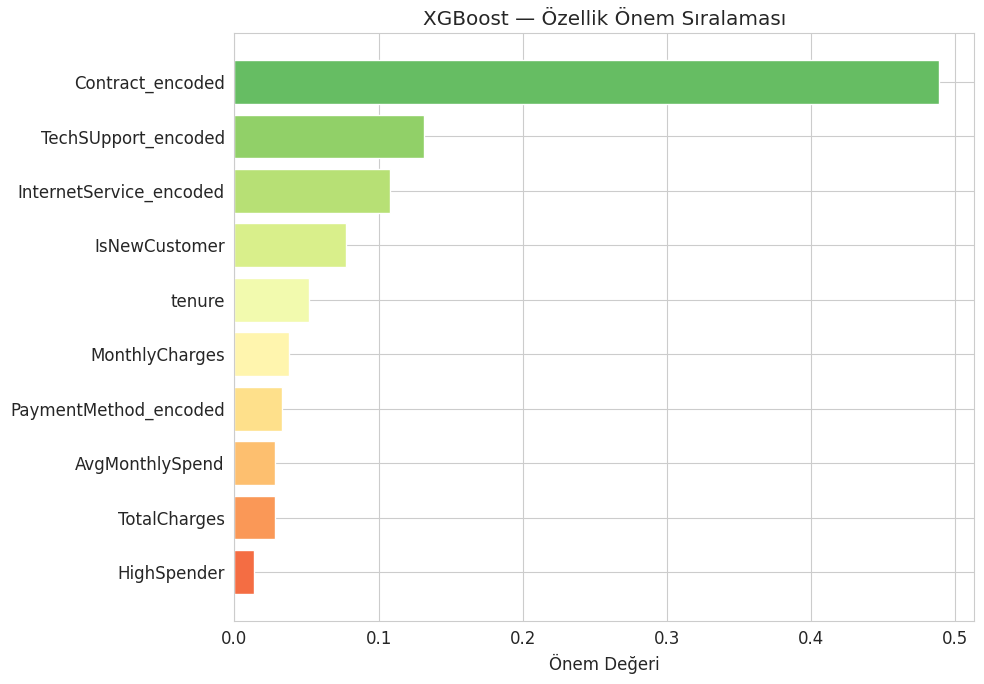

In [ ]:
plt.figure(figsize=(10, 7))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(imp_df)))
plt.barh(imp_df['Özellik'],
         imp_df['Önem'],
         color=colors,
         edgecolor='white')
plt.xlabel('Önem Değeri')
plt.title('XGBoost — Özellik Önem Sıralaması')
plt.tight_layout()
plt.show()

In [ ]:
print("\nEn önemli 5 özellik (Top 5 most important features):")
for _, row in imp_df.tail(5).iloc[::-1].iterrows():
    print(f"  {row['Özellik']:30s} → {row['Önem']:.4f}")


En önemli 5 özellik:
  Contract_encoded               → 0.4887
  TechSUpport_encoded            → 0.1317
  InternetService_encoded        → 0.1081
  IsNewCustomer                  → 0.0776
  tenure                         → 0.0520


Modelin tahminlerini 4 kategoride inceliyoruz:

|  | Tahmin: Kalan | Tahmin: Terk |
|--|--------------|-------------|
| **Gerçek: Kalan** | TN (Doğru) | FP (Yanlış alarm) |
| **Gerçek: Terk** | FN (Kaçırılan müşteri) | TP (Doğru terk tahmini) |

İş açısından:
- **FP (Yanlış alarm):** Terk etmeyecek müşteriye gereksiz indirim sunma → düşük maliyet
- **FN (Kaçırma):** Terk edecek müşteriyi fark etmeme → **yüksek maliyet** (müşteri kaybı)

/

We analyze the model's predictions in 4 categories:

|  | Predicted: Retained | Predicted: Churned |
|--|--------------|-------------|
| **Actual: Retained** | TN (True Negative) | FP (False Positive / False Alarm) |
| **Actual: Churned** | FN (False Negative / Missed Customer) | TP (True Positive) |

From a business perspective:
- **FP (False Alarm):** Offering unnecessary discounts to a customer who won't churn → Low cost
- **FN (Missed):** Failing to identify a customer who will churn → **High cost** (customer loss)


In [ ]:
cm=confusion_matrix(y_test, y_pred)
cm

array([[944,  91],
       [177, 197]])

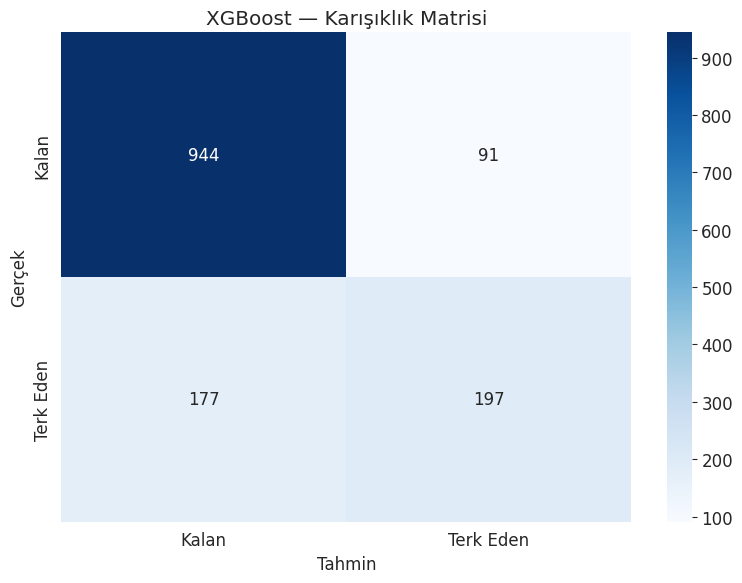

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Kalan', 'Terk Eden'],
            yticklabels=['Kalan', 'Terk Eden'])
plt.title('XGBoost — Karışıklık Matrisi')
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.tight_layout()
plt.show()

In [ ]:
# sınıflandırma için tüm metrikleri ortaya koyar / Generate the classification report with all metrics
class_report=classification_report(y_test, y_pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1035
           1       0.68      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### 7.2 ROC Eğrisi ve AUC

ROC eğrisi, farklı eşik değerlerinde modelin **Doğru Pozitif Oranı (TPR)** ile **Yanlış Pozitif Oranı (FPR)** arasındaki dengeyi gösterir.

- **AUC > 0.80:** İyi bir terk tahmin modeli
- **AUC > 0.85:** Üretim ortamına alınabilir düzeyde
- **AUC > 0.90:** Mükemmel

/

### 7.2 ROC Curve and AUC

The ROC curve shows the trade-off between the model's **True Positive Rate (TPR)** and **False Positive Rate (FPR)** at various threshold values.

- **AUC > 0.80:** Good churn prediction model
- **AUC > 0.85:** Production-ready performance
- **AUC > 0.90:** Excellent


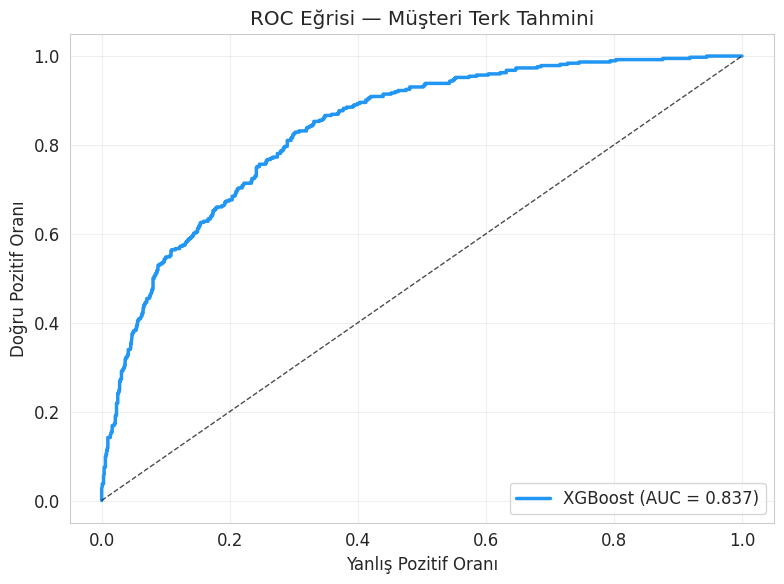

In [ ]:
# ROC eğrisi / ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2196F3', linewidth=2.5,
         label=f'XGBoost (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.7)
plt.xlabel('Yanlış Pozitif Oranı')
plt.ylabel('Doğru Pozitif Oranı')
plt.title('ROC Eğrisi — Müşteri Terk Tahmini')
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# BI (İş Zekası - İş Analitiği )
Ödev --- Yöneticiler Çıkarımlar

## 📊 Stratejik İş Zekası (BI) Raporu

### [TR] Müşteri Kaybı (Churn) Analizi ve Karar Destek Raporu

**1. Model Performans Göstergeleri:**
*   **Genel Doğruluk (Accuracy):** %81 — Her 5 müşteriden 4'ü doğru tahmin edilmektedir.
*   **Yakalama Oranı (Recall):** %53 — Terk edeceklerin yarısından fazlası önceden tespit edilebilmektedir.
*   **Model Kalitesi (AUC):** 0.837 — Endüstri standartlarına göre başarılı ve ayırt edici gücü yüksek bir modeldir.

**2. Temel Analiz ve Kritik Kayıp Faktörleri:**
*   **Sözleşme Tipi (En Kritik):** Karar sürecinin %49'unu etkiler. Aylık aboneler en yüksek risk grubudur.
*   **Teknik Destek Eksikliği:** Teknik destek almayan müşterilerde sadakat oranı belirgin şekilde düşüktür.
*   **İnternet Altyapısı (Fiber Optik):** Beklenti yönetimi veya teknik stabilite kaynaklı olarak, Fiber optik kullanıcıları DSL kullanıcılarına göre daha fazla terk eğilimi göstermektedir.
*   **Kritik Eşik (Tenure):** İlk 6 aydaki 'Yeni Müşteriler' en kırılgan segmenti oluşturmaktadır.

**3. Stratejik Aksiyon Önerileri:**
*   **Finansal Dönüşüm:** Aylık aboneleri yıllık paketlere geçirmek için özel sadakat indirimleri ve kampanyalar kurgulanmalı.
*   **Proaktif Müdahale:** Modelin 'riskli' işaretlediği müşterilere ve Fiber Optik kullanıcılarına yönelik proaktif teknik destek aramaları yapılmalı.
*   **Müşteri Deneyimi:** İlk 6 aylık dönem için özel bir 'Onboarding' (Alıştırma) ve hoş geldin programı geliştirilmeli.

---

### [EN] Business Intelligence & Strategic Analysis Report

**1. Model Performance Metrics:**
*   **Overall Accuracy:** 81% — Successfully predicting 4 out of 5 customer behaviors.
*   **Recall Rate:** 53% — Identifying more than half of the churn-prone customers proactively.
*   **Model Quality (AUC):** 0.837 — Considered 'Strong/Successful' by industry standards for predictive power.

**2. Key Insights & Critical Churn Drivers:**
*   **Contract Type (Primary Driver):** Accounts for 49% of the model’s importance. Month-to-month contracts represent the highest volatility.
*   **Technical Support:** Customers lacking technical support show a significantly lower retention rate.
*   **Fiber Optic Infrastructure:** Fiber users exhibit higher churn compared to DSL, indicating potential issues in service reliability or high-tier pricing expectations.
*   **The Critical Window (Tenure):** New customers in their first 6 months are the most vulnerable segment for attrition.

**3. Strategic Recommendations:**
*   **Contract Migration:** Launch incentive-based campaigns to transition high-risk monthly subscribers to long-term annual commitments.
*   **Proactive Retention:** Initiate 'Health Check' calls and technical outreach for customers flagged as high-risk by the model, especially within the Fiber Optic segment.
*   **Success Onboarding:** Implement a robust 180-day customer success program to strengthen brand loyalty during the initial high-risk period.